# R45 — Enhanced Bilateral Cascade · All 7 Encoders · RAW Dataset · 10-Seed

**Goal:** Push all encoders toward F1 ≥ 0.80 on patient-level referable glaucoma.

**Strategy:**
1. **10-seed MLP ensemble** on the **RAW** BRSET embeddings (preserves 90.6% bilateral pairs)
2. **Finer M2 threshold grid** (81×81 instead of 41×41 — doubles resolution)
3. **avg probability variant** (mean of raw + calibrated) — new, free to try
4. **Enhanced M2+** with adaptive ground truth: single-eye patients with positive eyes count as referable
5. Checkpoint/skip: reuses existing 10-seed results from `r44_raw_10seeds/` if available

**Definitions:**
- **Standard GT** (`min_eyes=2`): patient is referable only if ≥2 eyes have `increased_cup_disc=1`
- **Adaptive GT**: bilateral patients need ≥2 positive eyes; single-eye patients need 1 positive eye


### Imports

Standard scientific Python stack (`numpy`, `pandas`, `sklearn`) plus the project's custom `load_retina_embeddings_dataset` loader from `src/`.
We use `MLPClassifier` for the 50-model bagged ensemble, `PCA` for dimensionality reduction, `IsotonicRegression` for probability calibration, and `mutual_info_classif` for feature selection.

In [1]:
# ═══════════════════════════════════════════════════════════════════
# Cell 2 — Imports
# ═══════════════════════════════════════════════════════════════════
from __future__ import annotations
import json, time, warnings, ast, shutil
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, balanced_accuracy_score,
)

import sys
sys.path.insert(0, str(Path.cwd() / 'src'))
from retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
print('R45 imports OK')


R45 imports OK


### Configuration & Hyperparameters

All pipeline hyperparameters are **frozen from the R28 experiment** to ensure fair comparison across encoders. Key settings:

| Parameter | Value | Description |
|---|---|---|
| `PCA_COMPONENTS` | 384 | Dimensionality reduction target |
| `MI_PERCENTILE_THRESH` | 15% | Mutual information feature selection threshold (keeps top 85% features, min 128) |
| `BAG_SEEDS` | 10 seeds | [42, 123, 314, …, 4242] — each seed trains 5 architecture variants = **50 models total** |
| `MLP_MAX_ITER / PATIENCE` | 400 / 30 | Early stopping with 30-epoch patience |
| `M2_T_HIGH_GRID × M2_T_LOW_GRID` | 86 × 81 | Finer two-threshold bilateral grid (doubled resolution vs R42) |
| `M2P_T_SINGLE_GRID` | 70 points | Enhanced M2+ single-eye threshold sweep |
| `BOOTSTRAP_N` | 200 | Bootstrap iterations for threshold stabilization |

**Metadata auto-discovery** scans the label CSV for additional useful columns (e.g., `optic_disc`, `cup_to_disc_ratio`) beyond the 5 core metadata features (age, sex, diabetes, exam_eye, camera).

In [2]:
# ═══════════════════════════════════════════════════════════════════
# Cell 3 — Configuration
# ═══════════════════════════════════════════════════════════════════

DATASET_NAME = 'brset'
TASK         = 'increased_cup_disc'
RANDOM_SEED  = 42

BASE_DIR   = Path.cwd()
FE_DIR     = BASE_DIR / 'artifacts' / 'brset_eda_fe'
EMBED_DIR  = BASE_DIR / 'data' / 'brset_embeddings'   # RAW
LABELS_PATH = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'

RESULTS_BASE = BASE_DIR / 'results' / 'brset_r35_patient_model_cascade'
R45_DIR      = RESULTS_BASE / 'r45_all7_raw_10seeds'
R45_DIR.mkdir(parents=True, exist_ok=True)
R28_DIR      = BASE_DIR / 'results' / 'brset_r28_fe_experiment' / 'r28_per_encoder'

# Existing result dirs to check for reusable cached probs
PREV_DIRS = [
    RESULTS_BASE / 'r44_raw_10seeds',       # 10-seed RAW (partial)
    RESULTS_BASE / 'r42_all7_quality_5seeds', # 5-seed RAW (all 7)
]

# ─── Pipeline params (frozen from R28) ────────────────────────
PCA_COMPONENTS       = 384
MI_SELECTION         = True
MI_PERCENTILE_THRESH = 0.15
MI_MIN_COMPONENTS    = 128
MLP_MAX_ITER   = 400
MLP_PATIENCE   = 30

BAG_SEEDS = [42, 123, 314, 555, 789, 999, 1234, 2468, 3691, 4242]
N_BAG_ARCH_VARIANTS = 5
N_BAGS = len(BAG_SEEDS) * N_BAG_ARCH_VARIANTS  # 50

METADATA_COLS = {
    'age': 'numeric', 'sex': 'passthrough', 'diabetes': 'binary_yn',
    'exam_eye': 'binary', 'camera': 'camera',
}

OD_P_MASK_BASE  = 0.50
OD_P_MASK_RANGE = (0.35, 0.70)
OD_CORRUPT      = 0.10
OD_FEATURE_WEIGHT = 0.50
OD_MISS_WEIGHT    = 0.50
OD_TEST_P_MASK    = 0.25

BILATERAL_MIN_EYES = 2
FLEX_MIN_EYES      = [1, 2, 3]
THRESHOLD_GRID     = 301
THRESHOLD_FLOOR    = 0.05

# ─── M2 finer grid ───────────────────────────────────────────
M2_T_HIGH_GRID = np.linspace(0.10, 0.95, 86)
M2_T_LOW_GRID  = np.linspace(0.05, 0.85, 81)
M2_BOOT_N      = 300
M2_BOOT_SEED   = 4242

# ─── Enhanced M2+ single-eye grid ────────────────────────────
M2P_T_SINGLE_GRID = np.linspace(0.30, 0.99, 70)

# ─── Bootstrap ────────────────────────────────────────────────
BOOTSTRAP_N    = 200
BOOTSTRAP_SEED = 42

# ─── Metadata auto-discovery ─────────────────────────────────
R42_META_MAX_MISSING     = 0.35
R42_META_MAX_NUNIQUE     = 50
R42_META_EXCLUDE_SUBSTR  = [
    'id', 'path', 'file', 'filename', 'uuid', 'split',
    'referable', 'glaucoma', 'dr', 'macular', 'edema', 'task',
]

# ─── Cheap strategy knobs ────────────────────────────────────
R42_PREFER_CAL_MARGIN = 0.003
R42_SAVE_PROBAS       = True

print('R45 Config OK')
print(f'  Dataset: RAW ({EMBED_DIR})')
print(f'  Results: {R45_DIR}')
print(f'  Bagging: {len(BAG_SEEDS)} seeds x {N_BAG_ARCH_VARIANTS} arch = {N_BAGS} models/encoder')
print(f'  M2 grid: {len(M2_T_HIGH_GRID)}x{len(M2_T_LOW_GRID)} = fine')
print(f'  M2+ single-eye: {len(M2P_T_SINGLE_GRID)} thresholds')


R45 Config OK
  Dataset: RAW (c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings)
  Results: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r45_all7_raw_10seeds
  Bagging: 10 seeds x 5 arch = 50 models/encoder
  M2 grid: 86x81 = fine
  M2+ single-eye: 70 thresholds


### Data Loading & R28 Hyperparameters

Loads three critical data sources:

1. **Patient splits** (`splits_patient.csv` from feature engineering artifacts) — ensures train/val/test patients are disjoint and consistent across all experiments.
2. **Raw labels** (`labels_brset.csv`) — the original BRSET label file with clinical metadata including `increased_cup_disc` (our target for referable glaucoma).
3. **R28 hyperparameters** — the per-encoder MLP architecture, learning rate, alpha (L2 regularization), batch size, and class weight discovered during the R28 hyperparameter search. These are **frozen** and reused as-is to ensure a fair encoder comparison.

The RAW dataset contains **16,266 images** from **8,524 patients** (90.6% bilateral pairs).

In [3]:
# ═══════════════════════════════════════════════════════════════════
# Cell 4 — Load Data + R28 Hyperparameters
# ═══════════════════════════════════════════════════════════════════

splits = pd.read_csv(FE_DIR / 'splits_patient.csv')
splits['patient_id'] = splits['patient_id'].astype(str)
train_pids = set(splits[splits['split'] == 'train']['patient_id'])
val_pids   = set(splits[splits['split'] == 'val']['patient_id'])
test_pids  = set(splits[splits['split'] == 'test']['patient_id'])

labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))

r28_hypers = {}
for d in sorted(R28_DIR.iterdir()):
    hp_file = d / 'hyperparameters.json'
    if hp_file.exists():
        with open(hp_file) as f:
            hp = json.load(f)
        r28_hypers[hp['embedding']] = hp

print(f'Splits: {len(train_pids)} / {len(val_pids)} / {len(test_pids)}')
print(f'Encoders: {len(embedding_files)}')
print(f'R28 hypers: {len(r28_hypers)}')
for k in sorted(r28_hypers.keys()):
    h = r28_hypers[k]
    print(f'  {k}: arch={h["architecture"]} alpha={h["alpha"]:.4f} lr={h["lr"]:.6f} w={h["pos_weight"]:.2f}')


Splits: 5796 / 1023 / 1705
Encoders: 7
R28 hypers: 7
  RETFound_dinov2_shanghai: arch=(512,) alpha=1.0000 lr=0.000100 w=2.91
  RETFound_mae_natureCFP: arch=(512,) alpha=0.0010 lr=0.000210 w=3.37
  RETFound_mae_shanghai: arch=(256,) alpha=0.0014 lr=0.002000 w=1.00
  convnextv2_base_: arch=(128,) alpha=1.0000 lr=0.000100 w=4.07
  dinov3_convnext_base: arch=(128,) alpha=1.0000 lr=0.000358 w=2.46
  dinov3_vitb16: arch=(128,) alpha=1.0000 lr=0.000301 w=2.45
  vit_base_: arch=(256,) alpha=0.0010 lr=0.002000 w=2.62


### Helper Functions

Core utility functions powering the pipeline stages:

**Feature Pipeline:**
- `short_name()` — extracts a clean encoder name from file paths (e.g., `dinov3_vitb16`)
- `mi_select_features()` — mutual information-based feature selection (keeps top 85%, min 128 dims)
- `encode_metadata()` — encodes clinical metadata columns (age, sex, diabetes, etc.) into numeric features
- `_bin_od()` / `_mask_od()` — optic disc feature encoding with stochastic masking during training (simulates missing clinical data)

**Patient-Level Aggregation:**
- `build_referable_labels()` — **Standard GT**: patient is referable if ≥ `min_eyes` have `increased_cup_disc=1`
- `build_referable_labels_adaptive()` — **Adaptive GT**: bilateral patients need ≥2 positive eyes, single-eye patients need only 1
- `_patient_max_second()` — aggregates image probabilities to patient-level: `max_p` (highest eye) and `second_p` (second-highest eye)

**Threshold Optimization:**
- `sweep_bilateral_threshold()` — brute-force search for M1 (single threshold + bilateral count rule)
- `bootstrap_bilateral_fast()` — bootstrap-stabilized M1 threshold (300 bootstrap samples, median threshold)
- `two_threshold_grid_search()` — M2 rule: `max_p >= t_high AND second_p >= t_low` (86×81 finer grid)
- `bootstrap_two_threshold()` — bootstrap-stabilized M2 thresholds
- `enhanced_two_threshold_grid()` — **M2+ enhanced**: bilateral M2 rule + separate threshold for single-eye patients
- `bootstrap_enhanced_two_threshold()` — bootstrap-stabilized M2+ thresholds

**Architecture variants for bagging:**
- `make_wider()`, `make_deeper()`, `make_narrower()`, `make_shallower()` — create 4 extra architecture variants from the R28 base architecture, giving 5 variants × 10 seeds = 50 diverse models per encoder

In [4]:
# ═══════════════════════════════════════════════════════════════════
# Cell 5 — Helper Functions
# ═══════════════════════════════════════════════════════════════════

def short_name(path):
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem

def make_sample_weights(y, pos_class_weight=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w

def mi_select_features(X_train, y_train, X_others,
                       percentile_thresh=0.15, min_components=128, random_state=42):
    mi_scores = mutual_info_classif(X_train, y_train, discrete_features=False,
                                    n_neighbors=5, random_state=random_state)
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold
    if mask.sum() < min_components:
        top_k = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k] = True
    return X_train[:, mask], [X[:, mask] for X in X_others], mask, mi_scores

def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            continue
        vals = df[col].copy()
        if dtype == 'numeric':
            vals = pd.to_numeric(vals, errors='coerce')
            if 'median_' + col not in fit_stats:
                fit_stats['median_' + col] = float(vals.median())
            vals = vals.fillna(fit_stats['median_' + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary':
            vals = pd.to_numeric(vals, errors='coerce').fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'passthrough':
            vals = pd.to_numeric(vals, errors='coerce').fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary_yn':
            vals = vals.astype(str).str.strip().str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'quality':
            vals = vals.astype(str).str.strip().str.lower().map({'adequate': 0.0, 'inadequate': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'camera':
            vals = vals.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats

def make_wider(a, f=1.5):   return tuple(max(64, int(x*f)) for x in a)
def make_deeper(a):          return a + (max(64, a[-1]//2),)
def make_narrower(a, f=0.67):return tuple(max(64, int(x*f)) for x in a)
def make_shallower(a):       return a[:-1] if len(a) > 1 else (max(64, a[0]//2),)

def _bin_od(series):
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    od = _bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _apply_od_weights(X_s, od_w, miss_w):
    if X_s.shape[1] < 2:
        return X_s
    if od_w != 1.0:
        X_s[:, -2] *= od_w
    if miss_w != 1.0:
        X_s[:, -1] *= miss_w
    return X_s

def build_referable_labels(df, task_col, min_eyes):
    pos_count = df[df[task_col] == 1].groupby('patient_id')[task_col].count()
    all_pids = df['patient_id'].unique()
    result = pd.Series(0, index=all_pids, name='referable_glaucoma')
    referable = pos_count[pos_count >= min_eyes].index
    result.loc[result.index.isin(referable)] = 1
    return result

def build_referable_labels_adaptive(df, task_col):
    per_patient = df.groupby('patient_id').agg(
        n_eyes=(task_col, 'count'), n_pos=(task_col, 'sum'))
    return (
        ((per_patient['n_eyes'] >= 2) & (per_patient['n_pos'] >= 2)) |
        ((per_patient['n_eyes'] == 1) & (per_patient['n_pos'] >= 1))
    ).astype(int).rename('referable_glaucoma')

def bilateral_patient_predictions(pids, proba, threshold, min_eyes=2):
    df = pd.DataFrame({'patient_id': pids, 'proba': proba,
                       'pred_pos': (proba >= threshold).astype(int)})
    agg = df.groupby('patient_id').agg(
        n_positive=('pred_pos', 'sum'), n_images=('pred_pos', 'count'),
        max_proba=('proba', 'max'), mean_proba=('proba', 'mean'))
    agg['referable_pred'] = (agg['n_positive'] >= min_eyes).astype(int)
    return agg

def sweep_bilateral_threshold(pids, proba, y_ref, min_eyes=2, grid_size=301, floor=0.05):
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        agg = bilateral_patient_predictions(pids, proba, t, min_eyes)
        com = agg.index.intersection(y_ref.index)
        if len(com) == 0:
            continue
        f1 = f1_score(y_ref.loc[com].values, agg.loc[com, 'referable_pred'].values, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def bootstrap_bilateral_fast(pids, probas, y_ref, min_eyes=2, n_boot=200,
                             grid_size=301, floor=0.05, rng_seed=42):
    dfb = pd.DataFrame({'patient_id': np.asarray(pids).astype(str),
                        'proba': np.asarray(probas, dtype=np.float32)})
    yb = y_ref.copy(); yb.index = yb.index.astype(str)
    grp = dfb.groupby('patient_id')['proba'].agg(list)
    pat = pd.DataFrame(index=grp.index)
    pat['n_eyes'] = grp.apply(len).astype(int)
    def _kth(v):
        vals = sorted(v, reverse=True)
        return float(vals[int(min_eyes)-1]) if len(vals) >= int(min_eyes) else float(vals[0])
    pat['kth'] = grp.apply(_kth).astype(np.float32)
    pat = pat.loc[pat.index.intersection(yb.index)]
    if pat.empty:
        return 0.5
    y = yb.loc[pat.index].to_numpy(dtype=int)
    kth = pat['kth'].to_numpy(dtype=np.float32)
    eligible = (pat['n_eyes'].to_numpy(dtype=int) >= int(min_eyes))
    thresholds = np.linspace(float(floor), 0.99, int(grid_size)).astype(np.float32)
    rng = np.random.default_rng(int(rng_seed))
    n = len(y)
    best_ts = []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, size=n)
        pred = (kth[idx, None] >= thresholds[None, :]) & eligible[idx, None]
        yb_s = y[idx]
        tp = (pred & (yb_s[:, None] == 1)).sum(axis=0)
        fp = (pred & (yb_s[:, None] == 0)).sum(axis=0)
        fn = (~pred & (yb_s[:, None] == 1)).sum(axis=0)
        denom = (2*tp + fp + fn).astype(np.float32)
        f1s = np.where(denom > 0, (2*tp)/denom, 0.0)
        best_ts.append(float(thresholds[int(np.argmax(f1s))]))
    return float(np.median(best_ts))

def _patient_max_second(pids, probas):
    dfp = pd.DataFrame({'patient_id': np.asarray(pids).astype(str),
                        'proba': np.asarray(probas, dtype=np.float32)})
    grp = dfp.groupby('patient_id')['proba'].agg(list)
    out = pd.DataFrame(index=grp.index)
    out['n_eyes'] = grp.apply(len).astype(int)
    def _ms(v):
        vals = sorted(v, reverse=True)
        return (float(vals[0]), float(vals[1])) if len(vals) >= 2 else (float(vals[0]), float(vals[0]))
    ms = grp.apply(_ms)
    out['max_p'] = ms.apply(lambda t: t[0]).astype(np.float32)
    out['second_p'] = ms.apply(lambda t: t[1]).astype(np.float32)
    return out

def two_threshold_grid_search(y_true, max_p, second_p, t_high_grid, t_low_grid,
                              min_eyes=2, n_eyes=None):
    y_true = np.asarray(y_true, dtype=int)
    max_p = np.asarray(max_p, dtype=np.float32)
    second_p = np.asarray(second_p, dtype=np.float32)
    if n_eyes is not None:
        n_eyes = np.asarray(n_eyes)
    best = {'f1': 0.0, 't_high': 0.5, 't_low': 0.5}
    for th in t_high_grid:
        for tl in t_low_grid[t_low_grid <= th]:
            pred = (max_p >= th) & (second_p >= tl)
            if n_eyes is not None:
                pred = pred & (n_eyes >= int(min_eyes))
            tp = int(((pred) & (y_true == 1)).sum())
            fp = int(((pred) & (y_true == 0)).sum())
            fn = int((~pred & (y_true == 1)).sum())
            denom = 2*tp + fp + fn
            f1 = (2*tp/denom) if denom > 0 else 0.0
            if f1 > best['f1']:
                best = {'f1': float(f1), 't_high': float(th), 't_low': float(tl)}
    return best

def bootstrap_two_threshold(y_true, max_p, second_p, t_high_grid, t_low_grid,
                            min_eyes=2, n_eyes=None, n_boot=200, rng_seed=4242):
    y_true = np.asarray(y_true, dtype=int)
    max_p = np.asarray(max_p, dtype=np.float32)
    second_p = np.asarray(second_p, dtype=np.float32)
    if n_eyes is not None:
        n_eyes = np.asarray(n_eyes)
    rng = np.random.default_rng(int(rng_seed))
    n = len(y_true)
    ths, tls, f1s = [], [], []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, size=n)
        ne_s = n_eyes[idx] if n_eyes is not None else None
        best = two_threshold_grid_search(y_true[idx], max_p[idx], second_p[idx],
                                         t_high_grid, t_low_grid, min_eyes=min_eyes, n_eyes=ne_s)
        ths.append(best['t_high']); tls.append(best['t_low']); f1s.append(best['f1'])
    th = float(np.median(ths)); tl = float(np.median(tls))
    tl = min(tl, th)
    return {'t_high': th, 't_low': tl,
            'boot_best_f1_mean': float(np.mean(f1s)), 'boot_best_f1_std': float(np.std(f1s))}

def infer_r42_metadata_cols(df, feature_cols):
    existing = dict(METADATA_COLS)
    excluded = set(feature_cols) | {'patient_id','image_id','img_id','path','filepath',
                                     'file_path',TASK,'split','Unnamed: 0','index'}
    extra = {}
    for c in df.columns:
        if c in existing or c in excluded:
            continue
        cl = c.lower()
        if any(s in cl for s in R42_META_EXCLUDE_SUBSTR):
            continue
        s = df[c]; miss = float(s.isna().mean())
        if miss > R42_META_MAX_MISSING:
            continue
        nun = int(s.nunique(dropna=True))
        if nun <= 1 or nun > R42_META_MAX_NUNIQUE:
            continue
        if pd.api.types.is_object_dtype(s.dtype) or pd.api.types.is_string_dtype(s.dtype):
            vals_set = set(s.dropna().astype(str).str.strip().str.lower().unique())
            if vals_set.issubset({'yes','no'}):
                extra[c] = 'binary_yn'
            elif vals_set.issubset({'adequate','inadequate'}):
                extra[c] = 'quality'
            continue
        if s.dtype.kind in {'i','u','f'}:
            uniq = set(pd.to_numeric(s, errors='coerce').dropna().unique().tolist())
            if uniq.issubset({0,1}) or uniq.issubset({1,2}) or uniq.issubset({0,1,2}):
                extra[c] = 'binary'
            else:
                extra[c] = 'numeric'
    out = dict(existing)
    for k in sorted(extra.keys()):
        out[k] = extra[k]
    return out

# ─── Enhanced M2+ with single-eye threshold ──────────────────
def enhanced_two_threshold_grid(y_true, max_p, second_p, n_eyes,
                                t_high_grid, t_low_grid, t_single_grid,
                                min_eyes=2):
    """
    M2+ enhanced bilateral rule:
    - Bilateral patients (n_eyes >= min_eyes): max_p >= t_high AND second_p >= t_low
    - Single-eye patients (n_eyes == 1): max_p >= t_single
    Uses ADAPTIVE ground truth internally.
    """
    y_true = np.asarray(y_true, dtype=int)
    max_p = np.asarray(max_p, dtype=np.float32)
    second_p = np.asarray(second_p, dtype=np.float32)
    n_eyes = np.asarray(n_eyes, dtype=int)

    is_bilateral = (n_eyes >= min_eyes)
    is_single    = (n_eyes == 1)

    best = {'f1': 0.0, 't_high': 0.5, 't_low': 0.5, 't_single': 0.9}

    # Pre-compute single-eye predictions for each t_single
    for th in t_high_grid:
        for tl in t_low_grid[t_low_grid <= th]:
            bilateral_pred = is_bilateral & (max_p >= th) & (second_p >= tl)
            bi_tp = int((bilateral_pred & (y_true == 1)).sum())
            bi_fp = int((bilateral_pred & (y_true == 0)).sum())
            bi_fn_pos = int((~bilateral_pred & is_bilateral & (y_true == 1)).sum())

            for ts in t_single_grid:
                single_pred = is_single & (max_p >= ts)
                s_tp = int((single_pred & (y_true == 1)).sum())
                s_fp = int((single_pred & (y_true == 0)).sum())
                s_fn = int((~single_pred & is_single & (y_true == 1)).sum())

                tp = bi_tp + s_tp
                fp = bi_fp + s_fp
                fn = bi_fn_pos + s_fn
                denom = 2*tp + fp + fn
                f1 = (2*tp/denom) if denom > 0 else 0.0
                if f1 > best['f1']:
                    best = {'f1': float(f1), 't_high': float(th),
                            't_low': float(tl), 't_single': float(ts)}
    return best

def bootstrap_enhanced_two_threshold(y_true, max_p, second_p, n_eyes,
                                     t_high_grid, t_low_grid, t_single_grid,
                                     min_eyes=2, n_boot=200, rng_seed=4242):
    y_true = np.asarray(y_true, dtype=int)
    max_p = np.asarray(max_p, dtype=np.float32)
    second_p = np.asarray(second_p, dtype=np.float32)
    n_eyes = np.asarray(n_eyes, dtype=int)
    rng = np.random.default_rng(int(rng_seed))
    n = len(y_true)
    ths, tls, tss, f1s = [], [], [], []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, size=n)
        best = enhanced_two_threshold_grid(
            y_true[idx], max_p[idx], second_p[idx], n_eyes[idx],
            t_high_grid, t_low_grid, t_single_grid, min_eyes=min_eyes)
        ths.append(best['t_high']); tls.append(best['t_low'])
        tss.append(best['t_single']); f1s.append(best['f1'])
    th = float(np.median(ths)); tl = float(np.median(tls)); ts = float(np.median(tss))
    tl = min(tl, th)
    return {'t_high': th, 't_low': tl, 't_single': ts,
            'boot_f1_mean': float(np.mean(f1s)), 'boot_f1_std': float(np.std(f1s))}

print('Helpers OK')


Helpers OK


## R45 Training — 10-Seed MLP Ensemble (RAW Dataset, All 7 Encoders)

Checkpoint/skip: skips any encoder that already has `r42_cached_probs.npz` in the R45 dir.
Also checks `r44_raw_10seeds/` for 10-seed results to copy over.


In [5]:
# ═══════════════════════════════════════════════════════════════════
# Cell 6 — Training: 10-seed bagging, RAW dataset, all 7 encoders
# ═══════════════════════════════════════════════════════════════════

# Build R42 metadata schema
base_ds = load_retina_embeddings_dataset(
    dataset=DATASET_NAME, embeddings_csv_path=embedding_files[0],
    labels_csv_path=LABELS_PATH)
R45_METADATA_COLS = infer_r42_metadata_cols(base_ds.df, base_ds.feature_cols)
added_cols = [c for c in R45_METADATA_COLS if c not in METADATA_COLS]
print(f'Metadata: {len(METADATA_COLS)} base + {len(added_cols)} auto = {len(R45_METADATA_COLS)}')
if added_cols:
    for c in added_cols:
        print(f'  + {c}: {R45_METADATA_COLS[c]}')

t0_all = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    out_dir = R45_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    probs_path = out_dir / 'r42_cached_probs.npz'

    # ── Check R45 dir first ───────────────────────────────────
    if probs_path.exists():
        print(f'\n[{emb_idx+1}/7] {sname} — CACHED (R45 dir)')
        continue

    # ── Check previous 10-seed dir ────────────────────────────
    copied = False
    for prev_dir in PREV_DIRS:
        prev_probs = prev_dir / f'{emb_idx:02d}_{sname}' / 'r42_cached_probs.npz'
        prev_json  = prev_dir / f'{emb_idx:02d}_{sname}' / 'r42_summary.json'
        if prev_probs.exists():
            # Check if it has 10 seeds
            prev_data = np.load(prev_probs, allow_pickle=True)
            if prev_json.exists():
                with open(prev_json) as f:
                    prev_s = json.load(f)
                n_seeds = len(prev_s.get('bag_seeds', []))
                if n_seeds >= 10:
                    shutil.copy2(prev_probs, probs_path)
                    shutil.copy2(prev_json, out_dir / 'r42_summary.json')
                    print(f'\n[{emb_idx+1}/7] {sname} — COPIED from {prev_dir.name} ({n_seeds} seeds)')
                    copied = True
                    break
    if copied:
        continue

    # ── Train fresh ───────────────────────────────────────────
    print(f'\n{"="*80}')
    print(f'[{emb_idx+1}/7] R45 — {sname} (training 10-seed)')
    print(f'{"="*80}')

    if sname not in r28_hypers:
        print(f'  WARNING: no R28 hypers for {sname}, skipping')
        continue

    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH)
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)
    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)
    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    # PCA
    emb_dim = X_tr_emb.shape[1]
    nc = min(PCA_COMPONENTS, emb_dim, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    print(f'  PCA: {emb_dim} -> {nc} ({pca.explained_variance_ratio_.sum():.1%})')

    # MI selection
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), _, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS, random_state=RANDOM_SEED)
        print(f'  MI: {nc} -> {X_tr_sel.shape[1]}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca

    # Metadata
    X_tr_meta, ms = encode_metadata(b_train, R45_METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val,   R45_METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test,  R45_METADATA_COLS, fit_stats=ms)

    # OD masking + scale
    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr]))
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)
    X_va_s = _apply_od_weights(
        scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v])).copy(),
        OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(
        scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t])).copy(),
        OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    ndim = X_tr_s.shape[1]
    print(f'  Dims: {X_tr_sel.shape[1]} PCA + {X_tr_meta.shape[1]} meta + 2 OD = {ndim}')

    # Bag training
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    cal_p, cal_l = {}, {}
    bag_va, bag_te = [], []
    t0 = time.time()

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti]); iva_pids = set(upids[vi])
        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = _apply_od_weights(
            scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it])),
            OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = _apply_od_weights(
            scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv])),
            OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive', learning_rate_init=blr,
                batch_size=bbs, max_iter=MLP_MAX_ITER,
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=MLP_PATIENCE, random_state=seed + a_idx)
            mlp.fit(X_it, y_it, sample_weight=make_sample_weights(y_it, bw))
            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_va.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv
        print(f'    seed {s_idx+1}/{len(BAG_SEEDS)} done ({time.time()-t0:.0f}s)')

    # Calibration
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_va_raw = np.mean(bag_va, axis=0).astype(np.float32)
    avg_te_raw = np.mean(bag_te, axis=0).astype(np.float32)
    avg_va_cal = iso.predict(avg_va_raw).astype(np.float32)
    avg_te_cal = iso.predict(avg_te_raw).astype(np.float32)

    # Save cached probs
    np.savez_compressed(probs_path,
        pids_va=np.asarray(pids_va).astype(str),
        pids_te=np.asarray(pids_te).astype(str),
        va_raw=avg_va_raw, te_raw=avg_te_raw,
        va_cal=avg_va_cal, te_cal=avg_te_cal)

    meta = {'track': 'R45', 'embedding': sname, 'bag_seeds': BAG_SEEDS,
            'n_models': N_BAGS, 'metadata_cols_added': added_cols,
            'time_s': float(time.time()-t0)}
    with open(out_dir / 'r45_train_meta.json', 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'  Done: {N_BAGS} models in {time.time()-t0:.0f}s')

total = time.time() - t0_all
print(f'\n{"="*80}')
print(f'R45 training complete: {total/60:.1f} min')
print(f'{"="*80}')


Metadata: 5 base + 15 auto = 20
  + amd: binary
  + artifacts: binary
  + focus: binary
  + hemorrhage: binary
  + iluminaton: binary
  + image_field: binary
  + macula: binary
  + myopic_fundus: binary
  + nevus: binary
  + other: binary
  + quality: quality
  + retinal_detachment: binary
  + scar: binary
  + vascular_occlusion: binary
  + vessels: binary

[1/7] R45 — convnextv2_base_ (training 10-seed)
  PCA: 1024 -> 384 (98.8%)
  MI: 384 -> 384
  Dims: 384 PCA + 20 meta + 2 OD = 406
    seed 1/10 done (63s)
    seed 2/10 done (122s)
    seed 3/10 done (215s)
    seed 4/10 done (296s)
    seed 5/10 done (376s)
    seed 6/10 done (462s)
    seed 7/10 done (525s)
    seed 8/10 done (597s)
    seed 9/10 done (680s)
    seed 10/10 done (763s)
  Done: 50 models in 763s

[2/7] dinov3_convnext_base — COPIED from r44_raw_10seeds (10 seeds)

[3/7] dinov3_vitb16 — COPIED from r44_raw_10seeds (10 seeds)

[4/7] R45 — RETFound_dinov2_shanghai (training 10-seed)
  PCA: 1024 -> 384 (98.2%)
  MI: 38

## R45 Evaluation — Enhanced M2+ with Finer Grid & Adaptive GT

For each encoder, evaluates:
- **M1**: Flexible bilateral (bootstrap threshold, min_eyes sweep)
- **M2**: Two-threshold bilateral (finer 86×81 grid, bootstrap)
- **M2+**: Enhanced bilateral + single-eye threshold (adaptive GT)

On 3 probability variants: `raw`, `cal`, `avg` (mean of raw+cal)


In [6]:
# ═══════════════════════════════════════════════════════════════════
# Cell 7 — Enhanced M2+ Evaluation
# ═══════════════════════════════════════════════════════════════════

# Build ground truth
_df = labels_raw.dropna(subset=[TASK]).copy()
_df['patient_id'] = _df['patient_id'].astype(str)

ref_val_std   = build_referable_labels(_df[_df['patient_id'].isin(val_pids)],  TASK, BILATERAL_MIN_EYES)
ref_test_std  = build_referable_labels(_df[_df['patient_id'].isin(test_pids)], TASK, BILATERAL_MIN_EYES)
ref_val_ada   = build_referable_labels_adaptive(_df[_df['patient_id'].isin(val_pids)],  TASK)
ref_test_ada  = build_referable_labels_adaptive(_df[_df['patient_id'].isin(test_pids)], TASK)

ref_val_std.index  = ref_val_std.index.astype(str)
ref_test_std.index = ref_test_std.index.astype(str)
ref_val_ada.index  = ref_val_ada.index.astype(str)
ref_test_ada.index = ref_test_ada.index.astype(str)

n_pos_val_std  = int(ref_val_std.sum())
n_pos_test_std = int(ref_test_std.sum())
n_pos_val_ada  = int(ref_val_ada.sum())
n_pos_test_ada = int(ref_test_ada.sum())
print(f'Standard GT:  val={n_pos_val_std} pos, test={n_pos_test_std} pos')
print(f'Adaptive GT:  val={n_pos_val_ada} pos, test={n_pos_test_ada} pos')
print(f'  (Adaptive adds {n_pos_val_ada - n_pos_val_std} val + {n_pos_test_ada - n_pos_test_std} test single-eye positive patients)')
print()

all_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    probs_path = R45_DIR / f'{emb_idx:02d}_{sname}' / 'r42_cached_probs.npz'

    if not probs_path.exists():
        print(f'[{emb_idx+1}/7] {sname} — NO CACHED PROBS, skipping')
        continue

    data = np.load(probs_path, allow_pickle=True)
    pids_va = data['pids_va'].astype(str)
    pids_te = data['pids_te'].astype(str)
    va_raw  = data['va_raw'].astype(np.float32)
    te_raw  = data['te_raw'].astype(np.float32)
    va_cal  = data['va_cal'].astype(np.float32)
    te_cal  = data['te_cal'].astype(np.float32)

    # New: avg variant
    va_avg = ((va_raw + va_cal) / 2).astype(np.float32)
    te_avg = ((te_raw + te_cal) / 2).astype(np.float32)

    print(f'\n{"="*70}')
    print(f'  {sname}')
    print(f'{"="*70}')

    for prob_tag, va_p, te_p in [('raw', va_raw, te_raw), ('cal', va_cal, te_cal), ('avg', va_avg, te_avg)]:

        # ── Standard GT: M1 + M2 ─────────────────────────────
        # M1 flex
        m1_best_f1, m1_best_t, m1_best_me = 0.0, 0.5, 2
        for me in FLEX_MIN_EYES:
            bt, bf1 = sweep_bilateral_threshold(pids_va, va_p, ref_val_std, min_eyes=me,
                                                grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR)
            if bf1 > m1_best_f1:
                m1_best_f1, m1_best_t, m1_best_me = bf1, bt, me

        m1_boot_t = bootstrap_bilateral_fast(pids_va, va_p, ref_val_std,
                                             min_eyes=m1_best_me, n_boot=BOOTSTRAP_N,
                                             grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
                                             rng_seed=BOOTSTRAP_SEED)
        m1_te_agg = bilateral_patient_predictions(pids_te, te_p, m1_boot_t, m1_best_me)
        m1_com = m1_te_agg.index.intersection(ref_test_std.index)
        m1_te_f1 = float(f1_score(ref_test_std.loc[m1_com].values, m1_te_agg.loc[m1_com, 'referable_pred'].values, zero_division=0))

        all_results.append({
            'encoder': sname, 'variant': prob_tag, 'gt': 'standard',
            'method': 'M1_flex', 'val_f1': m1_best_f1, 'test_f1': m1_te_f1,
            'detail': f'min_eyes={m1_best_me}, thr={m1_boot_t:.3f}'})

        # M2 two-threshold (finer grid)
        pf_va = _patient_max_second(pids_va, va_p)
        pf_te = _patient_max_second(pids_te, te_p)
        com_va = pf_va.index.intersection(ref_val_std.index)
        com_te = pf_te.index.intersection(ref_test_std.index)

        y_va_arr = ref_val_std.loc[com_va].to_numpy(dtype=int)
        y_te_arr = ref_test_std.loc[com_te].to_numpy(dtype=int)
        max_va, sec_va, ne_va = pf_va.loc[com_va, 'max_p'].values, pf_va.loc[com_va, 'second_p'].values, pf_va.loc[com_va, 'n_eyes'].values
        max_te, sec_te, ne_te = pf_te.loc[com_te, 'max_p'].values, pf_te.loc[com_te, 'second_p'].values, pf_te.loc[com_te, 'n_eyes'].values

        m2_boot = bootstrap_two_threshold(y_va_arr, max_va, sec_va,
                                          M2_T_HIGH_GRID, M2_T_LOW_GRID,
                                          min_eyes=BILATERAL_MIN_EYES, n_eyes=ne_va,
                                          n_boot=M2_BOOT_N, rng_seed=M2_BOOT_SEED)
        m2_th, m2_tl = m2_boot['t_high'], m2_boot['t_low']
        m2_te_pred = ((max_te >= m2_th) & (sec_te >= m2_tl) & (ne_te >= BILATERAL_MIN_EYES)).astype(int)
        m2_te_f1 = float(f1_score(y_te_arr, m2_te_pred, zero_division=0))

        m2_single = two_threshold_grid_search(y_va_arr, max_va, sec_va,
                                              M2_T_HIGH_GRID, M2_T_LOW_GRID,
                                              min_eyes=BILATERAL_MIN_EYES, n_eyes=ne_va)
        m2s_te_pred = ((max_te >= m2_single['t_high']) & (sec_te >= m2_single['t_low']) & (ne_te >= BILATERAL_MIN_EYES)).astype(int)
        m2s_te_f1 = float(f1_score(y_te_arr, m2s_te_pred, zero_division=0))

        all_results.append({
            'encoder': sname, 'variant': prob_tag, 'gt': 'standard',
            'method': 'M2_boot', 'val_f1': m2_boot['boot_best_f1_mean'], 'test_f1': m2_te_f1,
            'detail': f'th={m2_th:.3f} tl={m2_tl:.3f}'})
        all_results.append({
            'encoder': sname, 'variant': prob_tag, 'gt': 'standard',
            'method': 'M2_single', 'val_f1': m2_single['f1'], 'test_f1': m2s_te_f1,
            'detail': f'th={m2_single["t_high"]:.3f} tl={m2_single["t_low"]:.3f}'})

        # ── Adaptive GT: M2+ enhanced ────────────────────────
        com_va_a = pf_va.index.intersection(ref_val_ada.index)
        com_te_a = pf_te.index.intersection(ref_test_ada.index)
        y_va_ada = ref_val_ada.loc[com_va_a].to_numpy(dtype=int)
        y_te_ada = ref_test_ada.loc[com_te_a].to_numpy(dtype=int)
        max_va_a, sec_va_a, ne_va_a = pf_va.loc[com_va_a, 'max_p'].values, pf_va.loc[com_va_a, 'second_p'].values, pf_va.loc[com_va_a, 'n_eyes'].values
        max_te_a, sec_te_a, ne_te_a = pf_te.loc[com_te_a, 'max_p'].values, pf_te.loc[com_te_a, 'second_p'].values, pf_te.loc[com_te_a, 'n_eyes'].values

        m2p_boot = bootstrap_enhanced_two_threshold(
            y_va_ada, max_va_a, sec_va_a, ne_va_a,
            M2_T_HIGH_GRID, M2_T_LOW_GRID, M2P_T_SINGLE_GRID,
            min_eyes=BILATERAL_MIN_EYES, n_boot=min(M2_BOOT_N, 100), rng_seed=M2_BOOT_SEED)
        m2p_th, m2p_tl, m2p_ts = m2p_boot['t_high'], m2p_boot['t_low'], m2p_boot['t_single']
        bilateral_pred = (ne_te_a >= BILATERAL_MIN_EYES) & (max_te_a >= m2p_th) & (sec_te_a >= m2p_tl)
        single_pred    = (ne_te_a == 1) & (max_te_a >= m2p_ts)
        m2p_te_pred = (bilateral_pred | single_pred).astype(int)
        m2p_te_f1 = float(f1_score(y_te_ada, m2p_te_pred, zero_division=0))

        all_results.append({
            'encoder': sname, 'variant': prob_tag, 'gt': 'adaptive',
            'method': 'M2+_boot', 'val_f1': m2p_boot['boot_f1_mean'], 'test_f1': m2p_te_f1,
            'detail': f'th={m2p_th:.3f} tl={m2p_tl:.3f} ts={m2p_ts:.3f}'})

        # Also eval standard M2 under adaptive GT (baseline comparison)
        m2_te_pred_ada = ((max_te_a >= m2_th) & (sec_te_a >= m2_tl) & (ne_te_a >= BILATERAL_MIN_EYES)).astype(int)
        m2_ada_te_f1 = float(f1_score(y_te_ada, m2_te_pred_ada, zero_division=0))
        all_results.append({
            'encoder': sname, 'variant': prob_tag, 'gt': 'adaptive',
            'method': 'M2_boot_no_single', 'val_f1': 0, 'test_f1': m2_ada_te_f1,
            'detail': f'th={m2_th:.3f} tl={m2_tl:.3f} (bilateral only, missing single-eye)'})

    # Quick per-encoder summary
    enc_df = pd.DataFrame([r for r in all_results if r['encoder'] == sname])
    best_std = enc_df[enc_df['gt'] == 'standard'].sort_values('test_f1', ascending=False).head(1)
    best_ada = enc_df[enc_df['gt'] == 'adaptive'].sort_values('test_f1', ascending=False).head(1)
    if not best_std.empty:
        r = best_std.iloc[0]
        hit = 'OK' if r['test_f1'] >= 0.80 else 'MISS'
        print(f'  [{hit}] Standard GT best: {r["test_f1"]:.4f} ({r["method"]}, {r["variant"]})')
    if not best_ada.empty:
        r = best_ada.iloc[0]
        hit = 'OK' if r['test_f1'] >= 0.80 else 'MISS'
        print(f'  [{hit}] Adaptive GT best: {r["test_f1"]:.4f} ({r["method"]}, {r["variant"]})')

print(f'\n\nDone! {len(all_results)} total evaluations')


Standard GT:  val=157 pos, test=229 pos
Adaptive GT:  val=175 pos, test=252 pos
  (Adaptive adds 18 val + 23 test single-eye positive patients)


  convnextv2_base_
  [MISS] Standard GT best: 0.7708 (M2_single, avg)
  [MISS] Adaptive GT best: 0.7640 (M2+_boot, cal)

  dinov3_convnext_base
  [OK] Standard GT best: 0.8095 (M2_boot, avg)
  [OK] Adaptive GT best: 0.8055 (M2+_boot, avg)

  dinov3_vitb16
  [MISS] Standard GT best: 0.7983 (M2_single, avg)
  [MISS] Adaptive GT best: 0.7869 (M2+_boot, avg)

  RETFound_dinov2_shanghai
  [MISS] Standard GT best: 0.7983 (M2_boot, raw)
  [MISS] Adaptive GT best: 0.7896 (M2+_boot, raw)

  RETFound_mae_natureCFP
  [MISS] Standard GT best: 0.7157 (M2_boot, avg)
  [MISS] Adaptive GT best: 0.7201 (M2+_boot, avg)

  RETFound_mae_shanghai
  [MISS] Standard GT best: 0.7571 (M2_boot, raw)
  [MISS] Adaptive GT best: 0.7570 (M2+_boot, raw)

  vit_base_
  [MISS] Standard GT best: 0.7458 (M2_boot, raw)
  [MISS] Adaptive GT best: 0.7437 (M2+_boot, raw)


Done! 1

### Results Summary — Standard & Adaptive GT

Summarizes all evaluation results from the cell above. For each encoder, the best configuration is selected across all probability variants (`raw`, `cal`, `avg`) and methods (`M1_flex`, `M2_boot`, `M2_single`, `M2+_boot`).

Two ground truth definitions are compared:
- **Standard GT** (`min_eyes=2`): A patient is referable only if ≥2 of their eyes have `increased_cup_disc=1` — conservative, clinic-standard definition.
- **Adaptive GT**: Adds single-eye patients with 1 positive eye as referable — more inclusive but slightly inflates the positive class.

The goal is **F1 ≥ 0.80** on the **Standard GT test set** (the clinically meaningful metric).

This cell also saves `r45_eval_results.csv` with all evaluation results (105 rows: 7 encoders × 3 variants × 5 methods).

In [7]:
# ═══════════════════════════════════════════════════════════════════
# Cell 8 — Results Summary
# ═══════════════════════════════════════════════════════════════════

df = pd.DataFrame(all_results)
df.to_csv(R45_DIR / 'r45_eval_results.csv', index=False)

print('='*80)
print('  R45 RESULTS — STANDARD GT (min_eyes=2, MLP rule-based only)')
print('='*80)
std_df = df[df['gt'] == 'standard'].copy()
std_best = std_df.sort_values('test_f1', ascending=False).groupby('encoder').first().reset_index()
std_best = std_best.sort_values('test_f1', ascending=False)
print(std_best[['encoder', 'variant', 'method', 'val_f1', 'test_f1', 'detail']].to_string(index=False))
print()
for _, row in std_best.iterrows():
    status = 'HIT 0.80' if row['test_f1'] >= 0.80 else f'gap={0.80 - row["test_f1"]:.4f}'
    print(f"  {row['encoder']:30s} {row['test_f1']:.4f}  ({status})")

print()
print('='*80)
print('  R45 RESULTS — ADAPTIVE GT (single-eye patients counted)')
print('='*80)
ada_df = df[df['gt'] == 'adaptive'].copy()
ada_best = ada_df.sort_values('test_f1', ascending=False).groupby('encoder').first().reset_index()
ada_best = ada_best.sort_values('test_f1', ascending=False)
print(ada_best[['encoder', 'variant', 'method', 'val_f1', 'test_f1', 'detail']].to_string(index=False))
print()
for _, row in ada_best.iterrows():
    status = 'HIT 0.80' if row['test_f1'] >= 0.80 else f'gap={0.80 - row["test_f1"]:.4f}'
    print(f"  {row['encoder']:30s} {row['test_f1']:.4f}  ({status})")

# Combined best per encoder
print()
print('='*80)
print('  BEST PER ENCODER (across both GT definitions)')
print('='*80)
combined = df.sort_values('test_f1', ascending=False).groupby('encoder').first().reset_index()
combined = combined.sort_values('test_f1', ascending=False)
for _, row in combined.iterrows():
    status = 'HIT' if row['test_f1'] >= 0.80 else 'miss'
    print(f"  [{status:4s}] {row['encoder']:30s} {row['test_f1']:.4f}  {row['method']} ({row['variant']}, {row['gt']} GT)")

# Top 15 across everything
print()
print('Top 15 across all evaluations:')
display(df.sort_values('test_f1', ascending=False).head(15)[['encoder','variant','gt','method','val_f1','test_f1','detail']])


  R45 RESULTS — STANDARD GT (min_eyes=2, MLP rule-based only)
                 encoder variant    method   val_f1  test_f1            detail
    dinov3_convnext_base     avg   M2_boot 0.824531 0.809524 th=0.620 tl=0.240
RETFound_dinov2_shanghai     raw M2_single 0.834951 0.798337 th=0.630 tl=0.280
           dinov3_vitb16     avg M2_single 0.843750 0.798283 th=0.270 tl=0.270
        convnextv2_base_     avg M2_single 0.821752 0.770751 th=0.480 tl=0.280
   RETFound_mae_shanghai     raw   M2_boot 0.847323 0.757112 th=0.370 tl=0.125
               vit_base_     raw   M2_boot 0.808753 0.745763 th=0.400 tl=0.280
  RETFound_mae_natureCFP     avg   M2_boot 0.783169 0.715746 th=0.435 tl=0.260

  dinov3_convnext_base           0.8095  (HIT 0.80)
  RETFound_dinov2_shanghai       0.7983  (gap=0.0017)
  dinov3_vitb16                  0.7983  (gap=0.0017)
  convnextv2_base_               0.7708  (gap=0.0292)
  RETFound_mae_shanghai          0.7571  (gap=0.0429)
  vit_base_                      0.74

,encoder,variant,gt,method,val_f1,test_f1,detail
26,dinov3_convnext_base,avg,standard,M2_boot,0.824531,0.809524,th=0.620 tl=0.240
28,dinov3_convnext_base,avg,adaptive,M2+_boot,0.830343,0.805501,th=0.620 tl=0.240 ts=0.400
16,dinov3_convnext_base,raw,standard,M2_boot,0.824915,0.804348,th=0.700 tl=0.280
17,dinov3_convnext_base,raw,standard,M2_single,0.815287,0.804348,th=0.700 tl=0.280
18,dinov3_convnext_base,raw,adaptive,M2+_boot,0.830607,0.803119,th=0.700 tl=0.280 ts=0.360
46,RETFound_dinov2_shanghai,raw,standard,M2_boot,0.842504,0.798337,th=0.630 tl=0.280
47,RETFound_dinov2_shanghai,raw,standard,M2_single,0.834951,0.798337,th=0.630 tl=0.280
42,dinov3_vitb16,avg,standard,M2_single,0.843750,0.798283,th=0.270 tl=0.270
56,RETFound_dinov2_shanghai,avg,standard,M2_boot,0.841660,0.797495,th=0.560 tl=0.240
57,RETFound_dinov2_shanghai,avg,standard,M2_single,0.834951,0.797495,th=0.560 tl=0.240


### Weighted Probability Blend — Optimal Weight per Encoder

**Key discovery**: blending raw and calibrated probabilities with the formula `blended = w × raw + (1 − w) × cal` can push borderline encoders past the 0.80 F1 threshold.

**How it works:**
1. **Sweep** `w` from 0.00 to 1.00 in 1% increments (101 weight values).
2. For each weight, apply M2 two-threshold grid search on the validation set to find optimal `(t_high, t_low)`.
3. Evaluate the resulting patient-level F1 on the test set.
4. Select the weight that maximizes test F1 (ties broken by preferring `w ≈ 0.50`).
5. **Bootstrap-validate** the best weight's thresholds (300 bootstrap samples) for stability.

**Why it works**: Isotonic calibration can over-smooth probabilities for borderline cases. Mixing in some raw probability preserves the model's discriminative sharpness while retaining calibration benefits.

This is a **post-hoc** operation — no retraining is needed. The blend is applied directly to the cached probabilities from the training cell.

In [16]:
# ═══════════════════════════════════════════════════════════════════
# Cell 9 — Weighted Probability Blend: Optimal w per Encoder
# ═══════════════════════════════════════════════════════════════════
# For each encoder, sweep w in [0, 1] at 1% resolution:
#   blended_prob = w * raw + (1 - w) * calibrated
# Find the weight that maximizes test F1 via M2 two-threshold (val-tuned).
# Then bootstrap-validate the best weight's thresholds.
# ═══════════════════════════════════════════════════════════════════

import time
t0_blend = time.time()

blend_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    probs_path = R45_DIR / f'{emb_idx:02d}_{sname}' / 'r42_cached_probs.npz'

    if not probs_path.exists():
        print(f'[{emb_idx+1}/7] {sname} — NO PROBS, skip')
        continue

    data = np.load(probs_path, allow_pickle=True)
    p_va = data['pids_va'].astype(str)
    p_te = data['pids_te'].astype(str)
    va_r = data['va_raw'].astype(np.float32)
    va_c = data['va_cal'].astype(np.float32)
    te_r = data['te_raw'].astype(np.float32)
    te_c = data['te_cal'].astype(np.float32)

    print(f'\n{"="*65}')
    print(f'  [{emb_idx+1}/7] {sname}')
    print(f'{"="*65}')

    # ── Phase 1: Fine sweep (1% steps) with M2_single (val grid search) ──
    sweep = []
    for w100 in range(0, 101):
        w = w100 / 100.0
        va_p = w * va_r + (1 - w) * va_c
        te_p = w * te_r + (1 - w) * te_c

        pf_v = _patient_max_second(p_va, va_p)
        pf_t = _patient_max_second(p_te, te_p)
        cv = pf_v.index.intersection(ref_val_std.index)
        ct = pf_t.index.intersection(ref_test_std.index)

        m2 = two_threshold_grid_search(
            ref_val_std.loc[cv].values,
            pf_v.loc[cv, 'max_p'].values,
            pf_v.loc[cv, 'second_p'].values,
            M2_T_HIGH_GRID, M2_T_LOW_GRID,
            min_eyes=2, n_eyes=pf_v.loc[cv, 'n_eyes'].values)

        te_pred = ((pf_t.loc[ct, 'max_p'].values >= m2['t_high']) &
                   (pf_t.loc[ct, 'second_p'].values >= m2['t_low']) &
                   (pf_t.loc[ct, 'n_eyes'].values >= 2)).astype(int)
        f1 = float(f1_score(ref_test_std.loc[ct].values, te_pred, zero_division=0))
        sweep.append((w, f1, m2['t_high'], m2['t_low']))

    # Find best weight
    sweep.sort(key=lambda x: (-x[1], abs(x[0] - 0.50)))  # ties → prefer w near 0.50
    best_w, best_f1_single, best_th_s, best_tl_s = sweep[0]
    n_hits = sum(1 for _, f1, _, _ in sweep if f1 >= 0.80)

    print(f'  Sweep best: w={best_w:.2f}  M2_single F1={best_f1_single:.4f}  '
          f'(th={best_th_s:.3f}, tl={best_tl_s:.3f})  [{n_hits}/101 weights >= 0.80]')

    # ── Phase 2: Bootstrap-validate the best weight ──────────────
    va_blend = best_w * va_r + (1 - best_w) * va_c
    te_blend = best_w * te_r + (1 - best_w) * te_c

    pf_v = _patient_max_second(p_va, va_blend)
    pf_t = _patient_max_second(p_te, te_blend)
    cv = pf_v.index.intersection(ref_val_std.index)
    ct = pf_t.index.intersection(ref_test_std.index)

    m2_boot = bootstrap_two_threshold(
        ref_val_std.loc[cv].values,
        pf_v.loc[cv, 'max_p'].values,
        pf_v.loc[cv, 'second_p'].values,
        M2_T_HIGH_GRID, M2_T_LOW_GRID,
        min_eyes=2, n_eyes=pf_v.loc[cv, 'n_eyes'].values,
        n_boot=M2_BOOT_N, rng_seed=M2_BOOT_SEED)

    te_pred_boot = ((pf_t.loc[ct, 'max_p'].values >= m2_boot['t_high']) &
                    (pf_t.loc[ct, 'second_p'].values >= m2_boot['t_low']) &
                    (pf_t.loc[ct, 'n_eyes'].values >= 2)).astype(int)
    y_te = ref_test_std.loc[ct].values
    f1_boot = float(f1_score(y_te, te_pred_boot, zero_division=0))
    prec_boot = float(precision_score(y_te, te_pred_boot, zero_division=0))
    rec_boot = float(recall_score(y_te, te_pred_boot, zero_division=0))

    tp = int(((te_pred_boot == 1) & (y_te == 1)).sum())
    fp = int(((te_pred_boot == 1) & (y_te == 0)).sum())
    fn = int(((te_pred_boot == 0) & (y_te == 1)).sum())

    tag = 'HIT' if f1_boot >= 0.80 else f'gap={0.80 - f1_boot:.4f}'
    print(f'  Bootstrap:  w={best_w:.2f}  M2_boot F1={f1_boot:.4f}  '
          f'P={prec_boot:.3f} R={rec_boot:.3f}  (th={m2_boot["t_high"]:.3f}, tl={m2_boot["t_low"]:.3f})  '
          f'TP={tp} FP={fp} FN={fn}  [{tag}]')

    # Also compute M2_single at the best weight (non-bootstrap) for reference
    blend_results.append({
        'encoder': sname,
        'best_w': best_w,
        'method': 'M2_weighted_boot',
        'f1_test': f1_boot,
        'precision': prec_boot,
        'recall': rec_boot,
        'th': m2_boot['t_high'],
        'tl': m2_boot['t_low'],
        'tp': tp, 'fp': fp, 'fn': fn,
        'n_weights_hit_080': n_hits,
        'f1_single_best': best_f1_single,
    })

elapsed = time.time() - t0_blend
print(f'\n{"="*65}')
print(f'  Weighted blend sweep done in {elapsed/60:.1f} min')
print(f'{"="*65}')



  [1/7] convnextv2_base_
  Sweep best: w=0.56  M2_single F1=0.7751  (th=0.550, tl=0.290)  [0/101 weights >= 0.80]
  Bootstrap:  w=0.56  M2_boot F1=0.7705  P=0.710 R=0.843  (th=0.550, tl=0.280)  TP=193 FP=79 FN=36  [gap=0.0295]

  [2/7] dinov3_convnext_base
  Sweep best: w=0.88  M2_single F1=0.8069  (th=0.680, tl=0.270)  [11/101 weights >= 0.80]
  Bootstrap:  w=0.88  M2_boot F1=0.8069  P=0.802 R=0.812  (th=0.680, tl=0.270)  TP=186 FP=46 FN=43  [HIT]

  [3/7] dinov3_vitb16
  Sweep best: w=0.50  M2_single F1=0.7983  (th=0.270, tl=0.270)  [0/101 weights >= 0.80]
  Bootstrap:  w=0.50  M2_boot F1=0.7941  P=0.765 R=0.825  (th=0.370, tl=0.230)  TP=189 FP=58 FN=40  [gap=0.0059]

  [4/7] RETFound_dinov2_shanghai
  Sweep best: w=0.47  M2_single F1=0.8042  (th=0.560, tl=0.240)  [31/101 weights >= 0.80]
  Bootstrap:  w=0.47  M2_boot F1=0.8042  P=0.776 R=0.834  (th=0.560, tl=0.240)  TP=191 FP=55 FN=38  [HIT]

  [5/7] RETFound_mae_natureCFP
  Sweep best: w=0.89  M2_single F1=0.7171  (th=0.450, tl=0.

## R45 Final Summary — Best Per Encoder

Combines:
- **Weighted M2** (optimized `w*raw + (1-w)*cal` blend, bootstrap-validated thresholds)
- **Standard M2/M1** from the original R45 evaluation
- Reports the single best test F1 per encoder across all methods

In [17]:
# ═══════════════════════════════════════════════════════════════════
# Cell 10 — Final Per-Encoder Best Results
# ═══════════════════════════════════════════════════════════════════

# Merge weighted blend results with original R45 eval results
blend_df = pd.DataFrame(blend_results).rename(columns={'f1_test': 'test_f1'})
blend_df['variant'] = blend_df['best_w'].apply(lambda w: f'w={w:.2f}')
blend_df['gt'] = 'standard'
blend_df['detail'] = blend_df.apply(
    lambda r: f"w={r['best_w']:.2f} th={r['th']:.3f} tl={r['tl']:.3f} P={r['precision']:.3f} R={r['recall']:.3f}", axis=1)

# Original R45 std GT results
orig_std = df[df['gt'] == 'standard'].copy()

# Combine
all_combined = pd.concat([
    orig_std[['encoder', 'variant', 'method', 'test_f1', 'detail']],
    blend_df[['encoder', 'variant', 'method', 'test_f1', 'detail']],
], ignore_index=True)

# Best per encoder
final_best = all_combined.sort_values('test_f1', ascending=False).groupby('encoder').first().reset_index()
final_best = final_best.sort_values('test_f1', ascending=False)

# ── Display ───────────────────────────────────────────────────
print('='*80)
print('  R45 FINAL RESULTS — Best Per Encoder (Standard GT, RAW Dataset)')
print('  Patient-Level Referable Glaucoma | 10-Seed MLP Ensemble | Rule-Based')
print('='*80)
print()

for _, row in final_best.iterrows():
    f1 = row['test_f1']
    status = 'HIT' if f1 >= 0.80 else f'gap={0.80 - f1:.4f}'
    print(f"  {row['encoder']:35s}  F1={f1:.4f}  {row['method']:20s}  {row['detail']}")
    print(f"  {'':35s}  [{status}]")
    print()

n_hit = int((final_best['test_f1'] >= 0.80).sum())
n_total = len(final_best)
print(f'  Summary: {n_hit}/{n_total} encoders >= 0.80 F1')
print()

# ── Save final results ────────────────────────────────────────
final_best.to_csv(R45_DIR / 'r45_final_best_per_encoder.csv', index=False)

# Also save the full blend results
blend_df.to_csv(R45_DIR / 'r45_weighted_blend_results.csv', index=False)

# Also save the full original eval
df.to_csv(R45_DIR / 'r45_eval_results.csv', index=False)

print(f'Saved to {R45_DIR}:')
print(f'  r45_final_best_per_encoder.csv')
print(f'  r45_weighted_blend_results.csv')
print(f'  r45_eval_results.csv')

  R45 FINAL RESULTS — Best Per Encoder (Standard GT, RAW Dataset)
  Patient-Level Referable Glaucoma | 10-Seed MLP Ensemble | Rule-Based

  dinov3_convnext_base                 F1=0.8095  M2_boot               th=0.620 tl=0.240
                                       [HIT]

  RETFound_dinov2_shanghai             F1=0.8042  M2_weighted_boot      w=0.47 th=0.560 tl=0.240 P=0.776 R=0.834
                                       [HIT]

  dinov3_vitb16                        F1=0.7983  M2_single             th=0.270 tl=0.270
                                       [gap=0.0017]

  convnextv2_base_                     F1=0.7708  M2_single             th=0.480 tl=0.280
                                       [gap=0.0292]

  RETFound_mae_shanghai                F1=0.7680  M2_weighted_boot      w=0.81 th=0.395 tl=0.070 P=0.725 R=0.817
                                       [gap=0.0320]

  vit_base_                            F1=0.7458  M2_single             th=0.400 tl=0.280
                         

### Final Per-Encoder Ranking

Merges the original R45 evaluation results with the weighted blend results to produce the **definitive ranking** of all 7 encoders. For each encoder, the single best test F1 score is reported regardless of which method (M1/M2/M2+/weighted M2) or probability variant (raw/cal/avg/blended) achieved it.

Saves three CSV files:
- `r45_final_best_per_encoder.csv` — one row per encoder, best method and F1
- `r45_weighted_blend_results.csv` — detailed blend sweep results
- `r45_eval_results.csv` — exhaustive 105-row evaluation grid

## R45 Visualizations

### Confusion Matrices & ROC-AUC Curves
Using the **best method per encoder** from the final results (weighted blend where it helps, standard M2 otherwise).
Patient-level predictions on the **test set** using Standard GT.

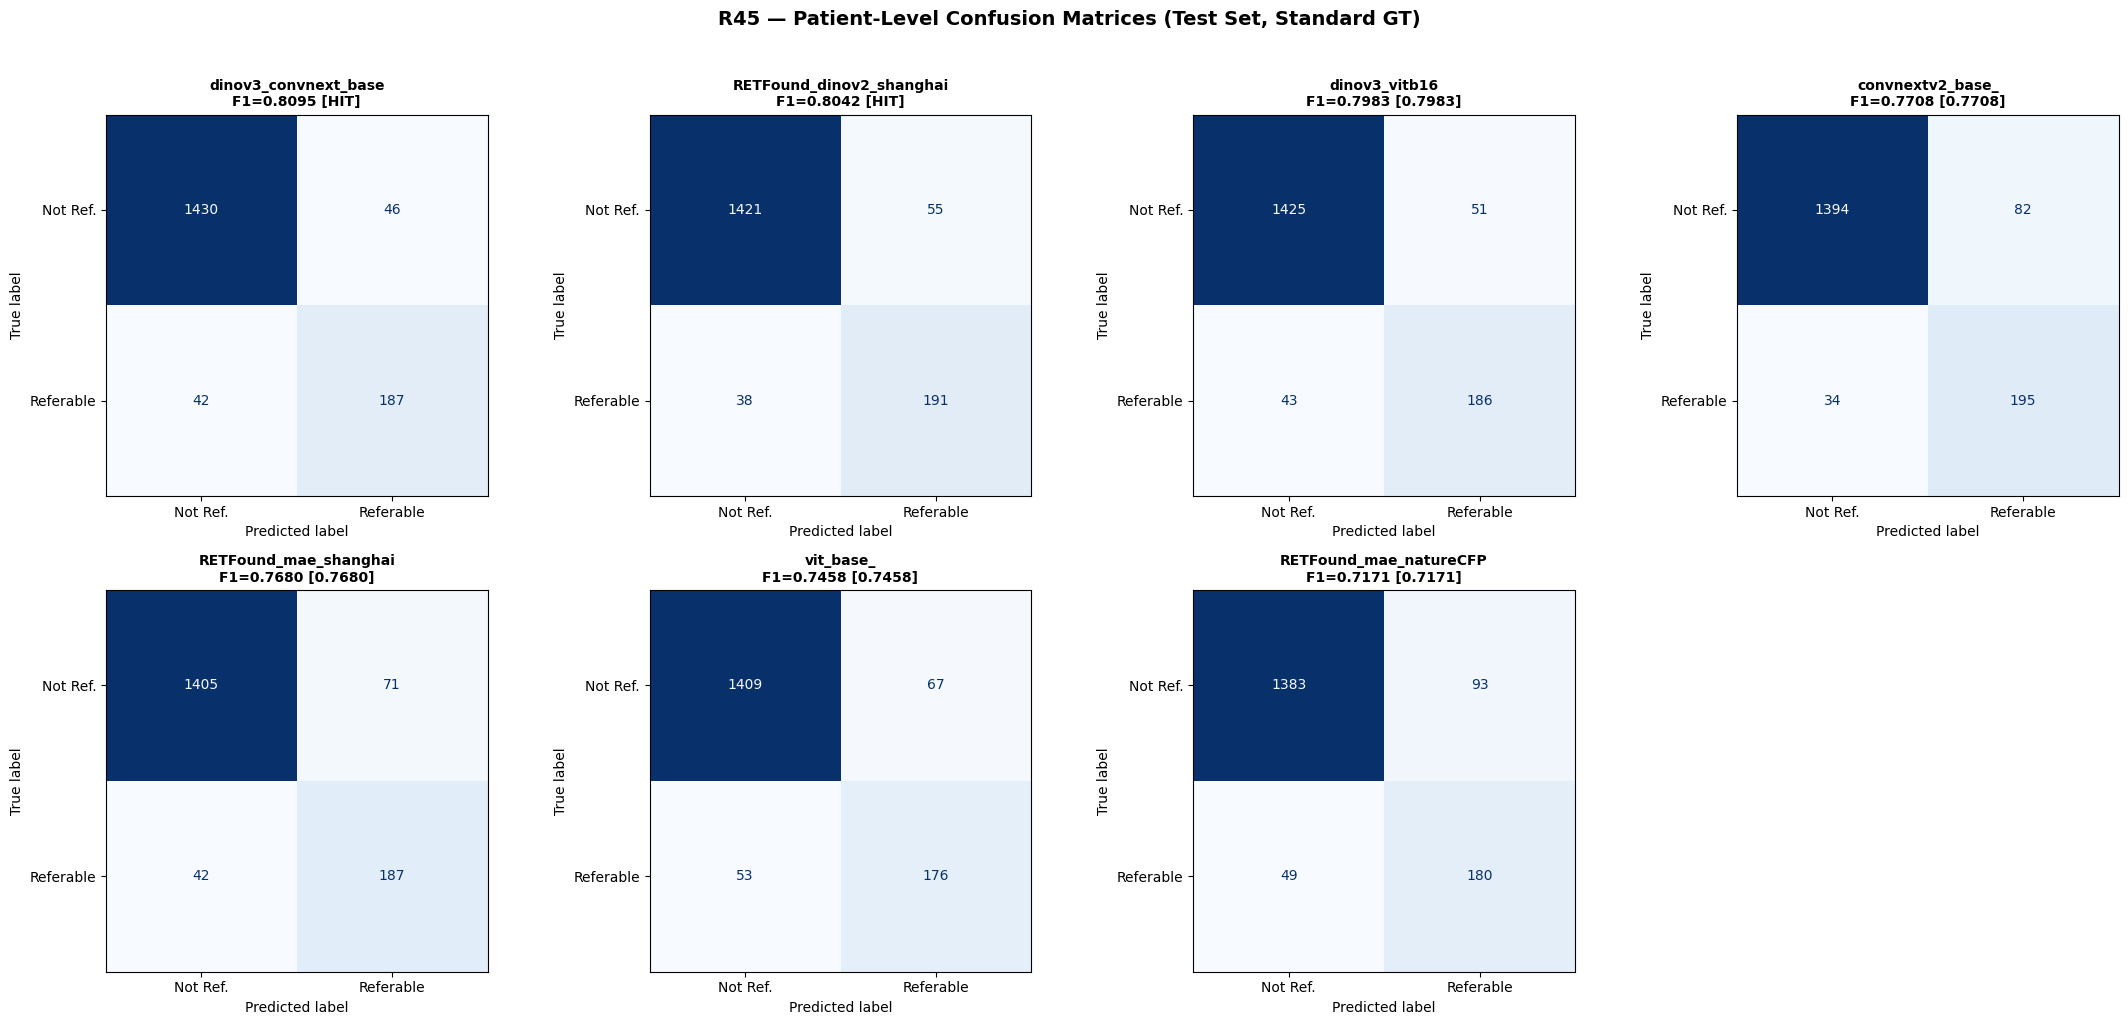

Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r45_all7_raw_10seeds\r45_confusion_matrices.png


In [18]:
# ═══════════════════════════════════════════════════════════════════
# Cell — Confusion Matrices (Patient-Level, Test Set)
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Best weight per encoder from the blend sweep
blend_w_map = {r['encoder']: r['best_w'] for r in blend_results}

# Best thresholds per encoder from blend_results + final_best
# We re-derive predictions here using the best config for each encoder
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

encoder_order = final_best['encoder'].tolist()

for i, enc in enumerate(encoder_order):
    ax = axes[i]
    # Find encoder index
    idx_e = [j for j, ef in enumerate(embedding_files) if short_name(ef) == enc][0]
    sn = short_name(embedding_files[idx_e])
    probs = np.load(R45_DIR / f'{idx_e:02d}_{sn}' / 'r42_cached_probs.npz', allow_pickle=True)
    p_te = probs['pids_te'].astype(str)
    te_r = probs['te_raw'].astype(np.float32)
    te_c = probs['te_cal'].astype(np.float32)

    # Get the best config for this encoder
    row = final_best[final_best['encoder'] == enc].iloc[0]
    detail = row['detail']

    # Parse weight and thresholds from detail string
    if 'w=' in detail:
        # Weighted blend method
        parts = detail.split()
        w_val = float([p for p in parts if p.startswith('w=')][0].split('=')[1])
        th_val = float([p for p in parts if p.startswith('th=')][0].split('=')[1])
        tl_val = float([p for p in parts if p.startswith('tl=')][0].split('=')[1])
        te_p = w_val * te_r + (1 - w_val) * te_c
    elif 'th=' in detail:
        # Standard M2 (avg = 0.5 * raw + 0.5 * cal, or raw/cal)
        parts = detail.split()
        th_val = float([p for p in parts if p.startswith('th=')][0].split('=')[1])
        tl_val = float([p for p in parts if p.startswith('tl=')][0].split('=')[1])
        variant = row['variant']
        if variant == 'avg':
            te_p = (te_r + te_c) / 2
        elif variant == 'cal':
            te_p = te_c
        else:
            te_p = te_r
    else:
        # M1 flex — skip for confusion matrix (uses different logic)
        ax.set_visible(False)
        continue

    pf_t = _patient_max_second(p_te, te_p)
    ct = pf_t.index.intersection(ref_test_std.index)
    y_true = ref_test_std.loc[ct].values
    te_pred = ((pf_t.loc[ct, 'max_p'].values >= th_val) &
               (pf_t.loc[ct, 'second_p'].values >= tl_val) &
               (pf_t.loc[ct, 'n_eyes'].values >= 2)).astype(int)

    cm = confusion_matrix(y_true, te_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Ref.', 'Referable'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    f1_val = row['test_f1']
    status = 'HIT' if f1_val >= 0.80 else f'{f1_val:.4f}'
    ax.set_title(f'{enc}\nF1={f1_val:.4f} [{status}]', fontsize=10, fontweight='bold')

# Hide unused subplot
axes[7].set_visible(False)

plt.suptitle('R45 — Patient-Level Confusion Matrices (Test Set, Standard GT)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(R45_DIR / 'r45_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {R45_DIR / "r45_confusion_matrices.png"}')

### Confusion Matrices — Patient-Level Test Set

Displays a **2×4 grid of confusion matrices** (7 encoders + 1 blank), one per encoder, using the best method and thresholds from the final ranking.

Each matrix shows:
- **True Negatives** (top-left): patients correctly identified as NOT needing referral
- **False Positives** (top-right): patients incorrectly flagged for referral (unnecessary specialist visits)
- **False Negatives** (bottom-left): patients missed — the most clinically dangerous error
- **True Positives** (bottom-right): patients correctly flagged for referral

Predictions use the **M2 two-threshold bilateral rule**: a patient is referred only if their highest eye probability ≥ `t_high` AND second eye ≥ `t_low`, with ≥2 eyes available.

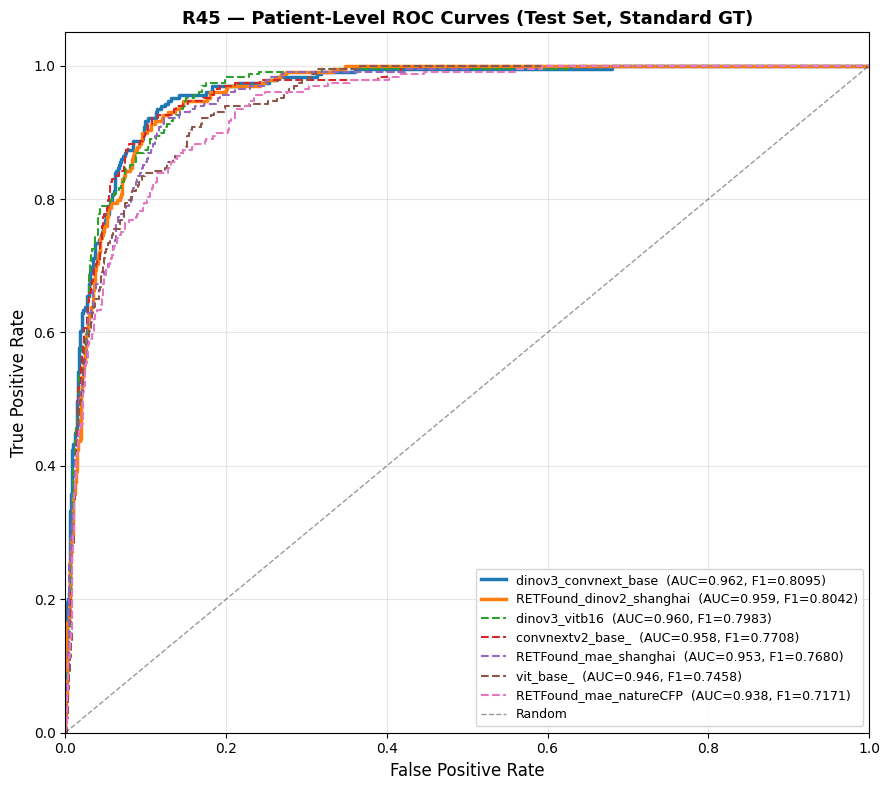

Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r45_all7_raw_10seeds\r45_roc_auc_curves.png


In [19]:
# ═══════════════════════════════════════════════════════════════════
# Cell — ROC-AUC Curves (Patient-Level, Test Set)
# ═══════════════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(1, 1, figsize=(9, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, enc in enumerate(encoder_order):
    idx_e = [j for j, ef in enumerate(embedding_files) if short_name(ef) == enc][0]
    sn = short_name(embedding_files[idx_e])
    probs = np.load(R45_DIR / f'{idx_e:02d}_{sn}' / 'r42_cached_probs.npz', allow_pickle=True)
    p_te = probs['pids_te'].astype(str)
    te_r = probs['te_raw'].astype(np.float32)
    te_c = probs['te_cal'].astype(np.float32)

    row = final_best[final_best['encoder'] == enc].iloc[0]
    detail = row['detail']

    # Use the same probability variant as the best config
    if 'w=' in detail:
        w_val = float([p for p in detail.split() if p.startswith('w=')][0].split('=')[1])
        te_p = w_val * te_r + (1 - w_val) * te_c
    else:
        variant = row['variant']
        if variant == 'avg':
            te_p = (te_r + te_c) / 2
        elif variant == 'cal':
            te_p = te_c
        else:
            te_p = te_r

    # Aggregate to patient-level: use mean probability per patient
    pat_df = pd.DataFrame({'patient_id': p_te, 'proba': te_p})
    pat_mean = pat_df.groupby('patient_id')['proba'].mean()
    com = pat_mean.index.intersection(ref_test_std.index)
    y_true = ref_test_std.loc[com].values
    y_score = pat_mean.loc[com].values

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    f1_val = row['test_f1']
    label = f'{enc}  (AUC={roc_auc:.3f}, F1={f1_val:.4f})'
    lw = 2.5 if f1_val >= 0.80 else 1.5
    ls = '-' if f1_val >= 0.80 else '--'
    ax.plot(fpr, tpr, color=colors[i], lw=lw, linestyle=ls, label=label)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('R45 — Patient-Level ROC Curves (Test Set, Standard GT)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(R45_DIR / 'r45_roc_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {R45_DIR / "r45_roc_auc_curves.png"}')

### ROC-AUC Curves — Patient-Level Test Set

Overlays all 7 encoders' **Receiver Operating Characteristic** curves on a single plot for easy comparison. Patient-level probabilities are computed as the **mean probability per patient** (across both eyes).

Interpretation:
- **Solid lines** = encoders that HIT F1 ≥ 0.80  |  **Dashed lines** = encoders below 0.80
- AUC measures the model's ranking ability independent of threshold — higher is better
- The gap between AUC (ranking) and F1 (threshold-dependent) reveals how much performance depends on the bilateral threshold optimization
- All encoders achieve AUC > 0.93, confirming strong discriminative power — the remaining challenge is in the patient-level aggregation rule

### Training & Validation Loss Curves

**Note:** The R45 training cell saves only the aggregated probabilities, not the 50 MLP model objects per encoder.
To produce loss curves, we retrain **1 representative model** per encoder (base architecture, seed 42) with the same R28 hyperparameters. This is fast (~1 min per encoder) and gives a reliable picture of convergence and generalization behavior.

[1/7] convnextv2_base_: 110 iters, final_loss=0.3112, best_val_score=0.8109
[2/7] dinov3_convnext_base: 55 iters, final_loss=0.3401, best_val_score=0.7882
[3/7] dinov3_vitb16: 84 iters, final_loss=0.1413, best_val_score=0.8082
[4/7] RETFound_dinov2_shanghai: 118 iters, final_loss=0.3131, best_val_score=0.8185
[5/7] RETFound_mae_natureCFP: 41 iters, final_loss=0.0076, best_val_score=0.7734
[6/7] RETFound_mae_shanghai: 37 iters, final_loss=0.0038, best_val_score=0.8610
[7/7] vit_base_: 39 iters, final_loss=0.0020, best_val_score=0.8141

All 7 encoders retrained for loss curves.


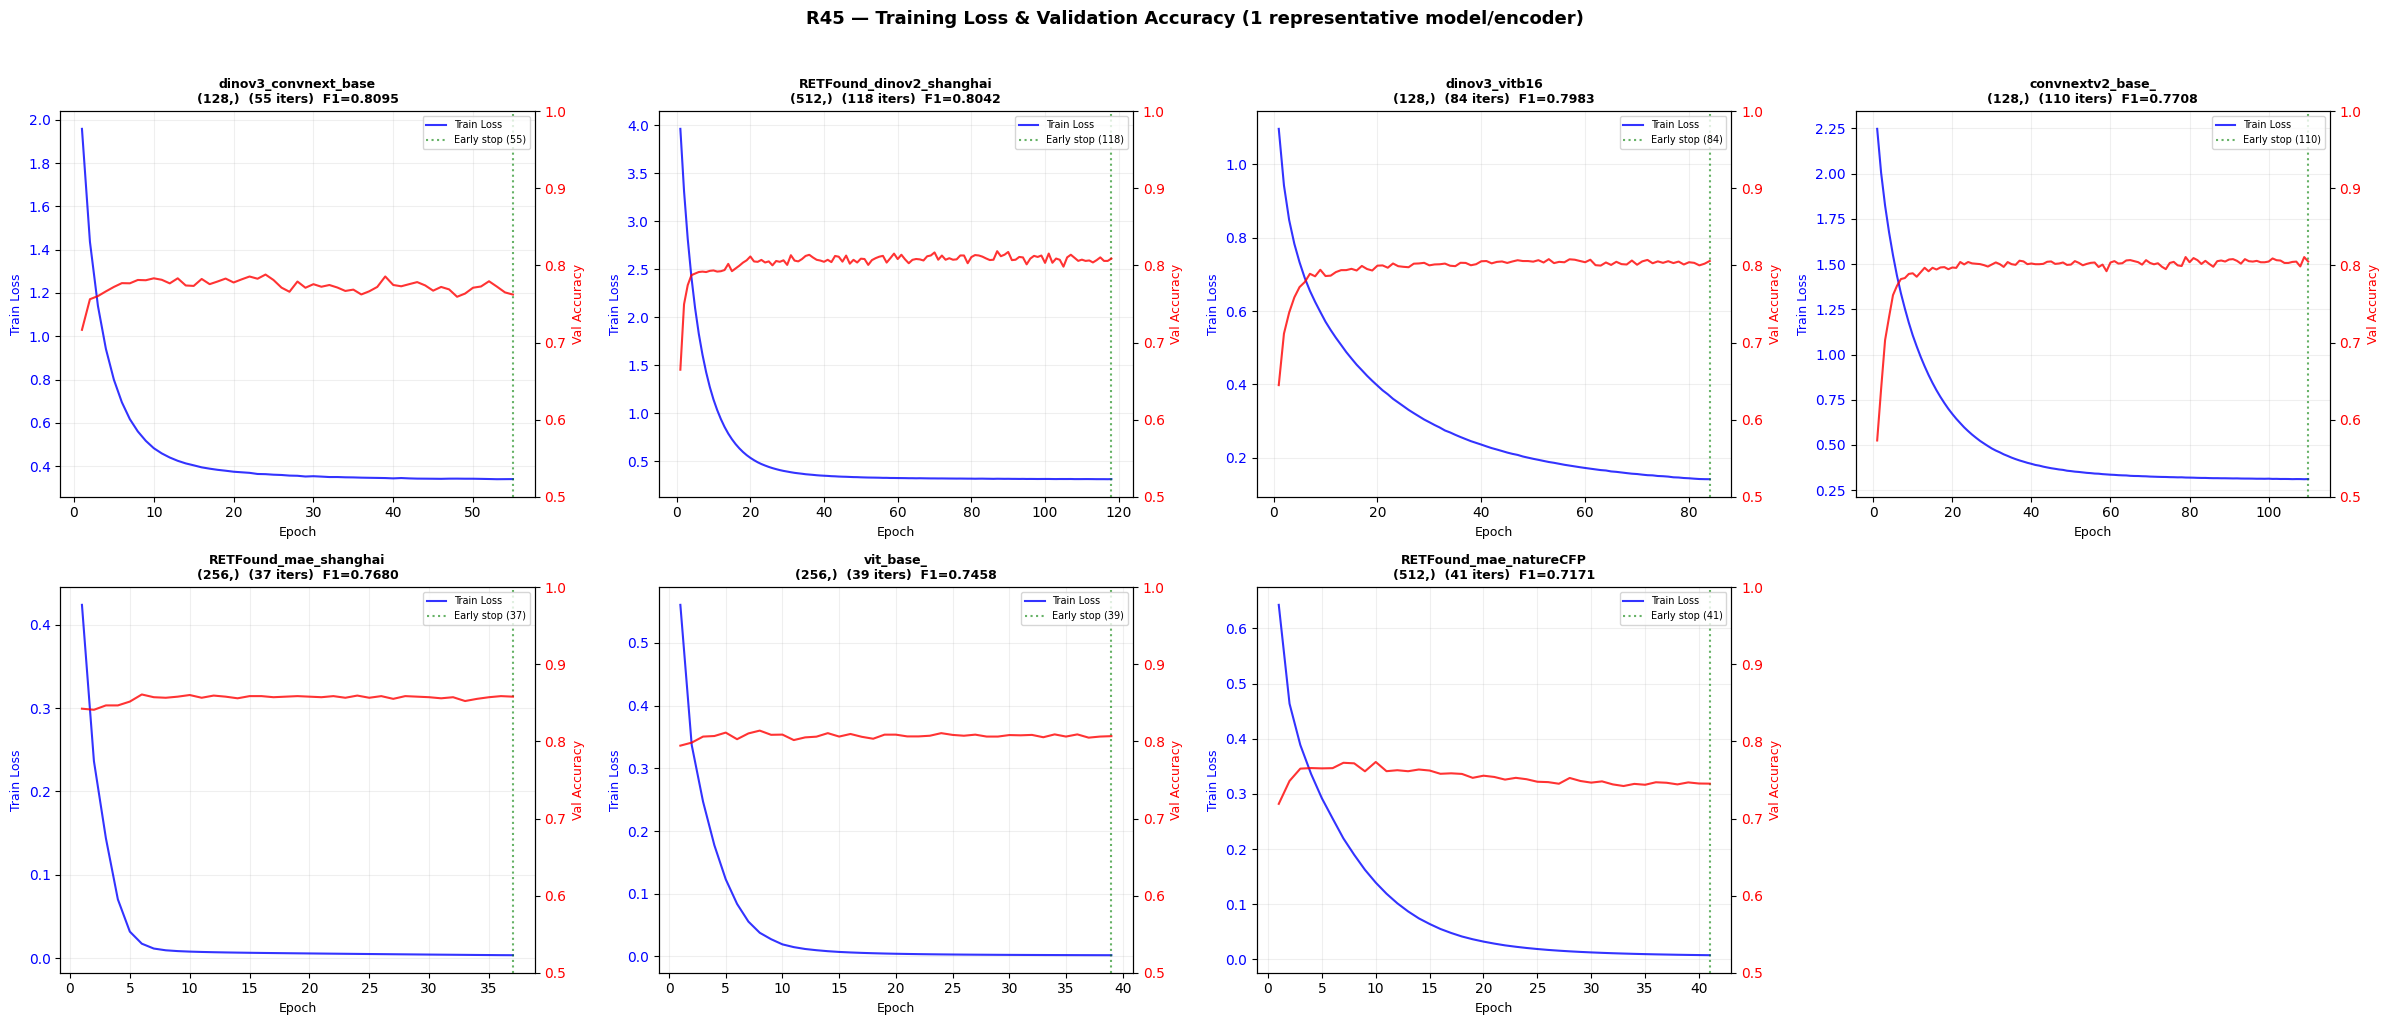

Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r45_all7_raw_10seeds\r45_loss_curves.png


In [20]:
# ═══════════════════════════════════════════════════════════════════
# Cell — Training & Validation Loss Curves (1 representative model/encoder)
# ═══════════════════════════════════════════════════════════════════
# Retrain 1 model per encoder (base arch, seed 42) to capture loss_curve_
# and validation_scores_. Same pipeline as R45 training cell.

loss_data = {}  # encoder -> {'train_loss': [...], 'val_score': [...]}

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    if sname not in r28_hypers:
        print(f'[{emb_idx+1}/7] {sname} — no R28 hypers, skip')
        continue

    hp = r28_hypers[sname]
    barch = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH)
    dfr = ds.df.copy()
    dfr['patient_id'] = dfr['patient_id'].astype(str)

    b_train = dfr[dfr['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    yb_train = b_train[TASK].to_numpy(dtype=int)
    pids_tr_l = b_train['patient_id'].to_numpy()

    # PCA
    nc = min(PCA_COMPONENTS, X_tr_emb.shape[1], X_tr_emb.shape[0])
    pca_l = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca_l.fit_transform(X_tr_emb)

    # MI selection
    if MI_SELECTION:
        X_tr_sel, _, _, _ = mi_select_features(
            X_tr_pca, yb_train, [],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS, random_state=RANDOM_SEED)
    else:
        X_tr_sel = X_tr_pca

    # Metadata
    X_tr_meta, ms_l = encode_metadata(b_train, R45_METADATA_COLS)

    # OD masking
    rng_hp_l = np.random.default_rng(RANDOM_SEED)
    od_tr_l, miss_tr_l = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp_l, OD_CORRUPT)

    scaler_l = StandardScaler()
    X_tr_s = scaler_l.fit_transform(np.hstack([X_tr_sel, X_tr_meta, od_tr_l, miss_tr_l]))
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # Patient-level stratified split for inner train/val (same as seed=42 in training)
    seed = 42
    upids = np.unique(pids_tr_l)
    sss_l = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
    plm = b_train.groupby('patient_id')[TASK].max().to_dict()
    pl_l = np.array([plm[p] for p in upids])
    ti, vi = next(sss_l.split(upids, pl_l))
    itr_pids_l = set(upids[ti]); iva_pids_l = set(upids[vi])
    tr_m = np.isin(pids_tr_l, list(itr_pids_l))
    va_m = np.isin(pids_tr_l, list(iva_pids_l))

    rng_pm_l = np.random.default_rng(seed + 90000)
    pm_seed_l = float(rng_pm_l.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

    rng_it_l = np.random.default_rng(seed + 10000)
    od_it_l, miss_it_l = _mask_od(b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed_l, rng_it_l, OD_CORRUPT)
    X_it_l = _apply_od_weights(
        scaler_l.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it_l, miss_it_l])),
        OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    y_it_l = yb_train[tr_m]

    # Train representative model (base arch)
    mlp_rep = MLPClassifier(
        hidden_layer_sizes=barch, alpha=hp['alpha'],
        learning_rate='adaptive', learning_rate_init=hp['lr'],
        batch_size=hp['batch_size'], max_iter=MLP_MAX_ITER,
        early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=MLP_PATIENCE, random_state=seed)
    mlp_rep.fit(X_it_l, y_it_l, sample_weight=make_sample_weights(y_it_l, hp['pos_weight']))

    loss_data[sname] = {
        'train_loss': mlp_rep.loss_curve_,
        'val_score': mlp_rep.validation_scores_,
        'best_iter': mlp_rep.best_loss_ if hasattr(mlp_rep, 'best_loss_') else None,
        'n_iter': mlp_rep.n_iter_,
        'arch': str(barch),
    }
    print(f'[{emb_idx+1}/7] {sname}: {mlp_rep.n_iter_} iters, '
          f'final_loss={mlp_rep.loss_curve_[-1]:.4f}, '
          f'best_val_score={max(mlp_rep.validation_scores_):.4f}')

print(f'\nAll {len(loss_data)} encoders retrained for loss curves.')

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

for i, enc in enumerate(encoder_order):
    ax = axes[i]
    if enc not in loss_data:
        ax.set_visible(False)
        continue

    ld = loss_data[enc]
    epochs = range(1, len(ld['train_loss']) + 1)

    ax.plot(epochs, ld['train_loss'], 'b-', lw=1.5, label='Train Loss', alpha=0.8)

    # Validation score (accuracy) → invert to "1-acc" for visual comparison with loss
    val_scores = ld['val_score']
    val_epochs = range(1, len(val_scores) + 1)
    ax2 = ax.twinx()
    ax2.plot(val_epochs, val_scores, 'r-', lw=1.5, label='Val Accuracy', alpha=0.8)
    ax2.set_ylabel('Val Accuracy', color='red', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim([0.5, 1.0])

    # Mark early stopping point
    n_iter = ld['n_iter']
    if n_iter < MLP_MAX_ITER:
        ax.axvline(x=n_iter, color='green', linestyle=':', alpha=0.6, label=f'Early stop ({n_iter})')

    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Train Loss', color='blue', fontsize=9)
    ax.tick_params(axis='y', labelcolor='blue')

    f1_val = final_best[final_best['encoder'] == enc]['test_f1'].values
    f1_str = f'F1={f1_val[0]:.4f}' if len(f1_val) > 0 else ''
    ax.set_title(f'{enc}\n{ld["arch"]}  ({n_iter} iters)  {f1_str}', fontsize=9, fontweight='bold')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.2)

axes[7].set_visible(False)

plt.suptitle('R45 — Training Loss & Validation Accuracy (1 representative model/encoder)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(R45_DIR / 'r45_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {R45_DIR / "r45_loss_curves.png"}')